# Stage 8 — SPY Exploratory Data Analysis
This notebook inspects the processed feature set using time-aware summaries and reusable plotting code from `src/eda.py`. The charts support the risk-monitoring question; they are descriptive and do not imply causality.

In [1]:
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
import pandas as pd
from IPython.display import Image, display
from src.eda import eda_summary


In [2]:
features = pd.read_csv('data/processed/spy_features.csv', parse_dates=['date'])
summary = eda_summary(features)
display(summary)
print('Rows:', len(features), 'Date range:', features.date.min().date(), 'to', features.date.max().date())
print('High-volatility target rate:', round(features.target_high_vol_next.mean(), 3))


,count,mean,median,std,min,max,skew,missing
open,2451.0,4.141147e+02,3.967200e+02,1.436464e+02,2.196700e+02,7.785400e+02,0.674146,0
high,2451.0,4.163442e+02,3.999900e+02,1.442280e+02,2.202500e+02,7.793700e+02,0.668988,0
low,2451.0,4.116771e+02,3.935600e+02,1.429708e+02,2.182600e+02,7.754300e+02,0.678573,0
close,2451.0,4.141813e+02,3.969200e+02,1.436703e+02,2.195700e+02,7.778800e+02,0.673368,0
adjusted_close,2451.0,3.926608e+02,3.776731e+02,1.526412e+02,1.879774e+02,7.778800e+02,0.681545,0
volume,2451.0,7.893543e+07,7.059130e+07,3.837446e+07,2.027000e+07,3.922207e+08,2.741869,0
return_1d,2451.0,6.374405e-04,7.724194e-04,1.140733e-02,-1.094239e-01,1.050195e-01,-0.311288,0
return_robust_z,2451.0,-1.268604e-02,6.226386e-03,1.598325e+00,-1.543381e+01,1.461269e+01,-0.311288,0
return_lag_1,2451.0,6.392175e-04,7.724194e-04,1.140807e-02,-1.094239e-01,1.050195e-01,-0.311609,0
momentum_5,2451.0,3.151283e-03,4.959746e-03,2.333699e-02,-1.796929e-01,1.735816e-01,-0.796356,0


Rows: 2451 Date range: 2016-11-22 to 2026-08-25
High-volatility target rate: 0.255


price_and_volatility.png


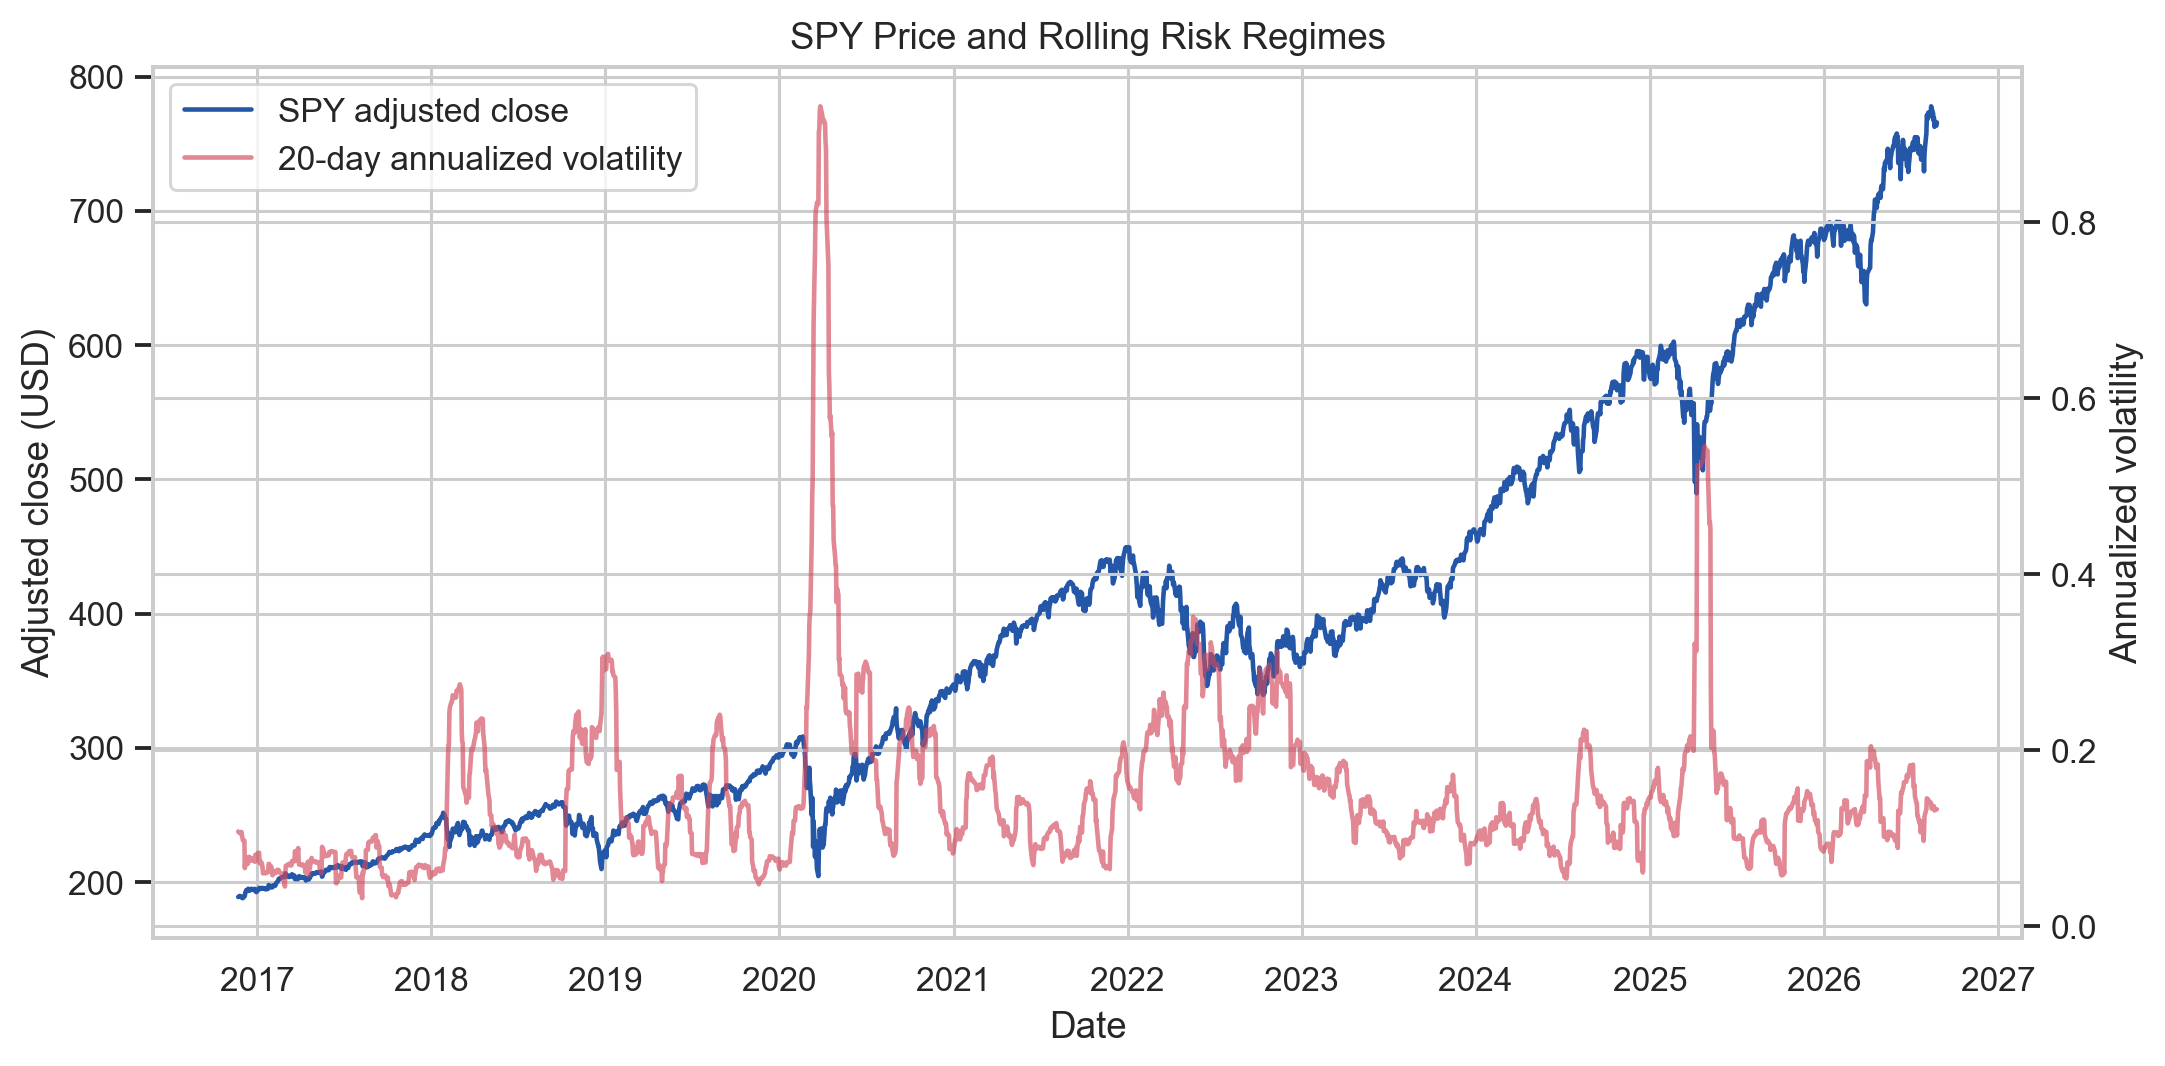

feature_coefficients.png


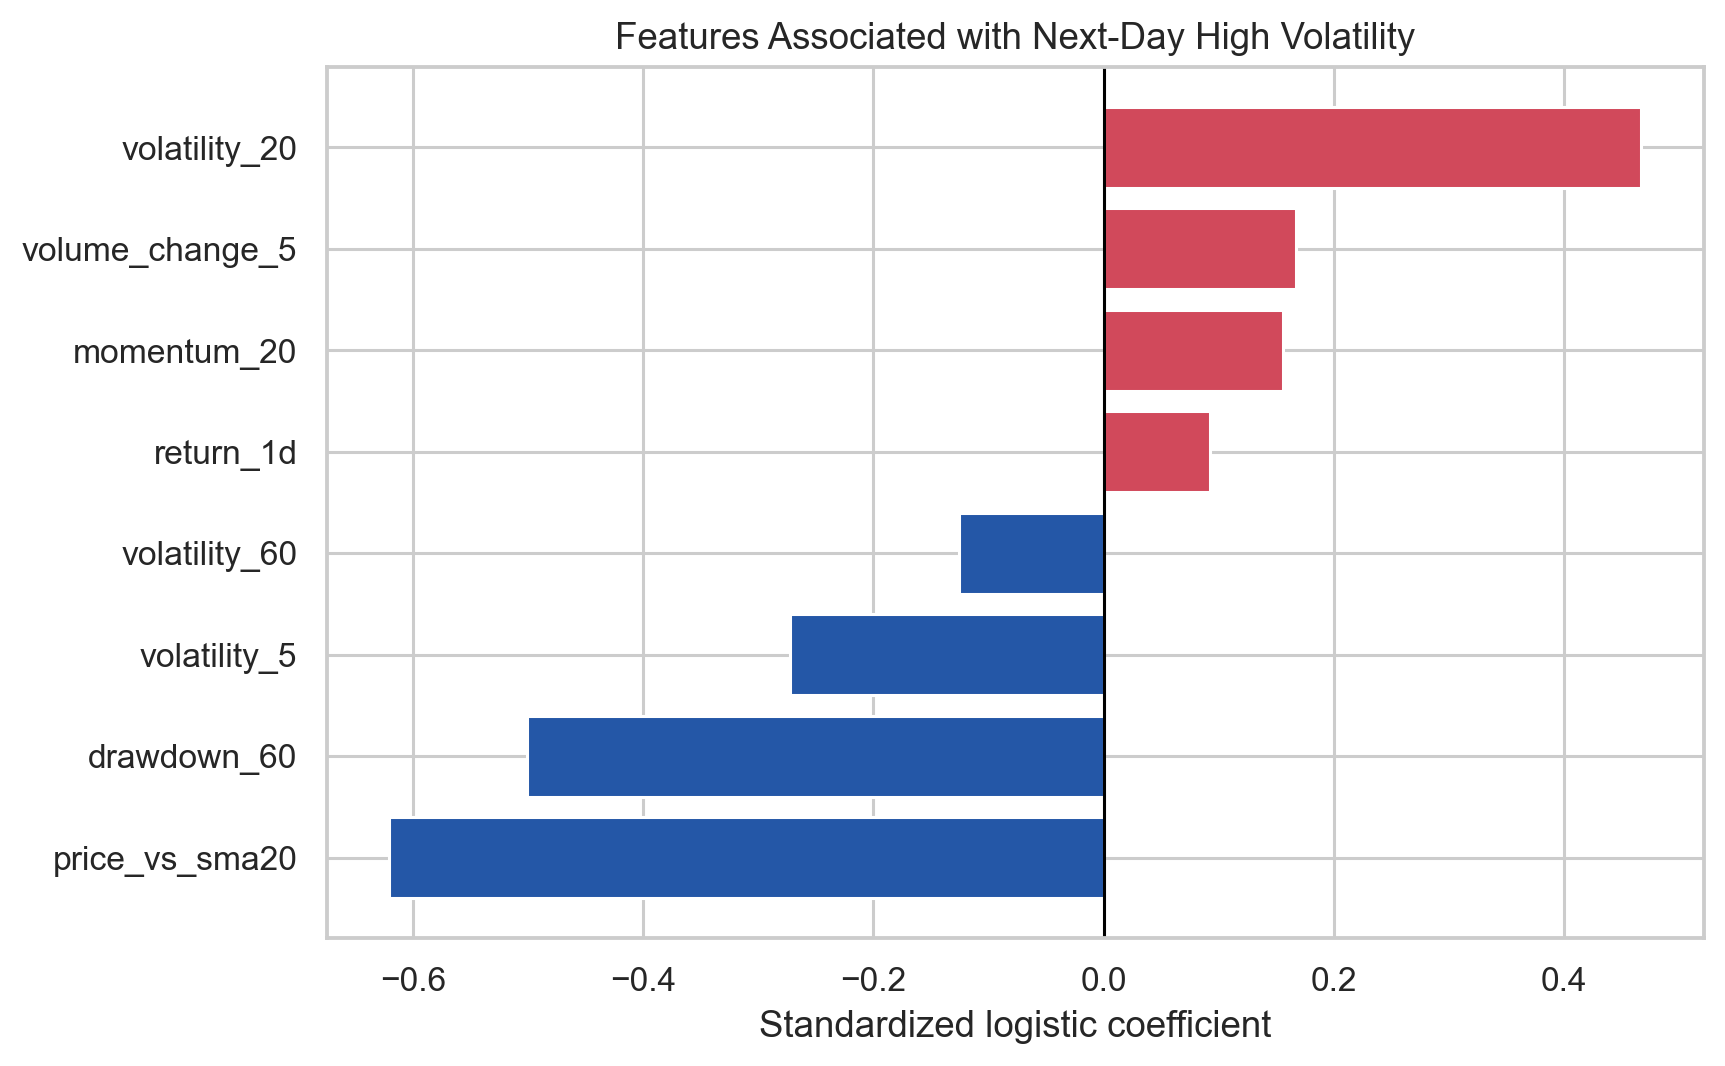

scenario_sensitivity.png


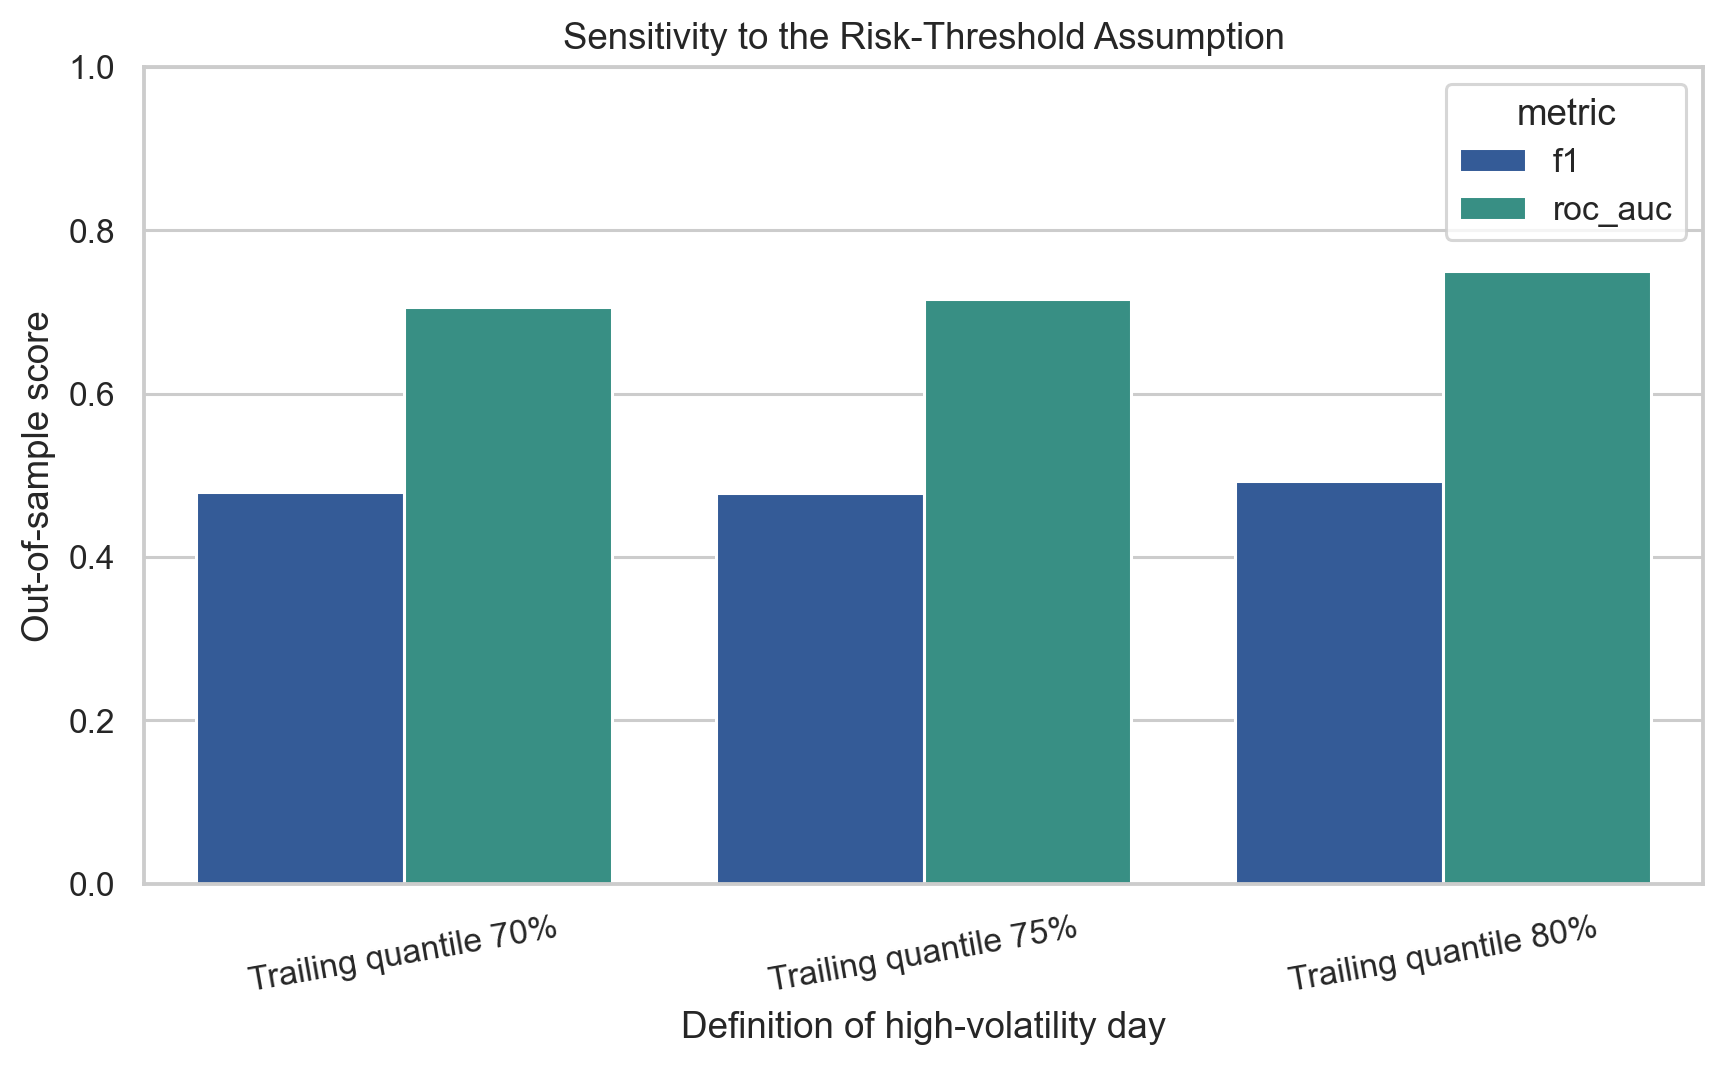

subgroup_performance.png


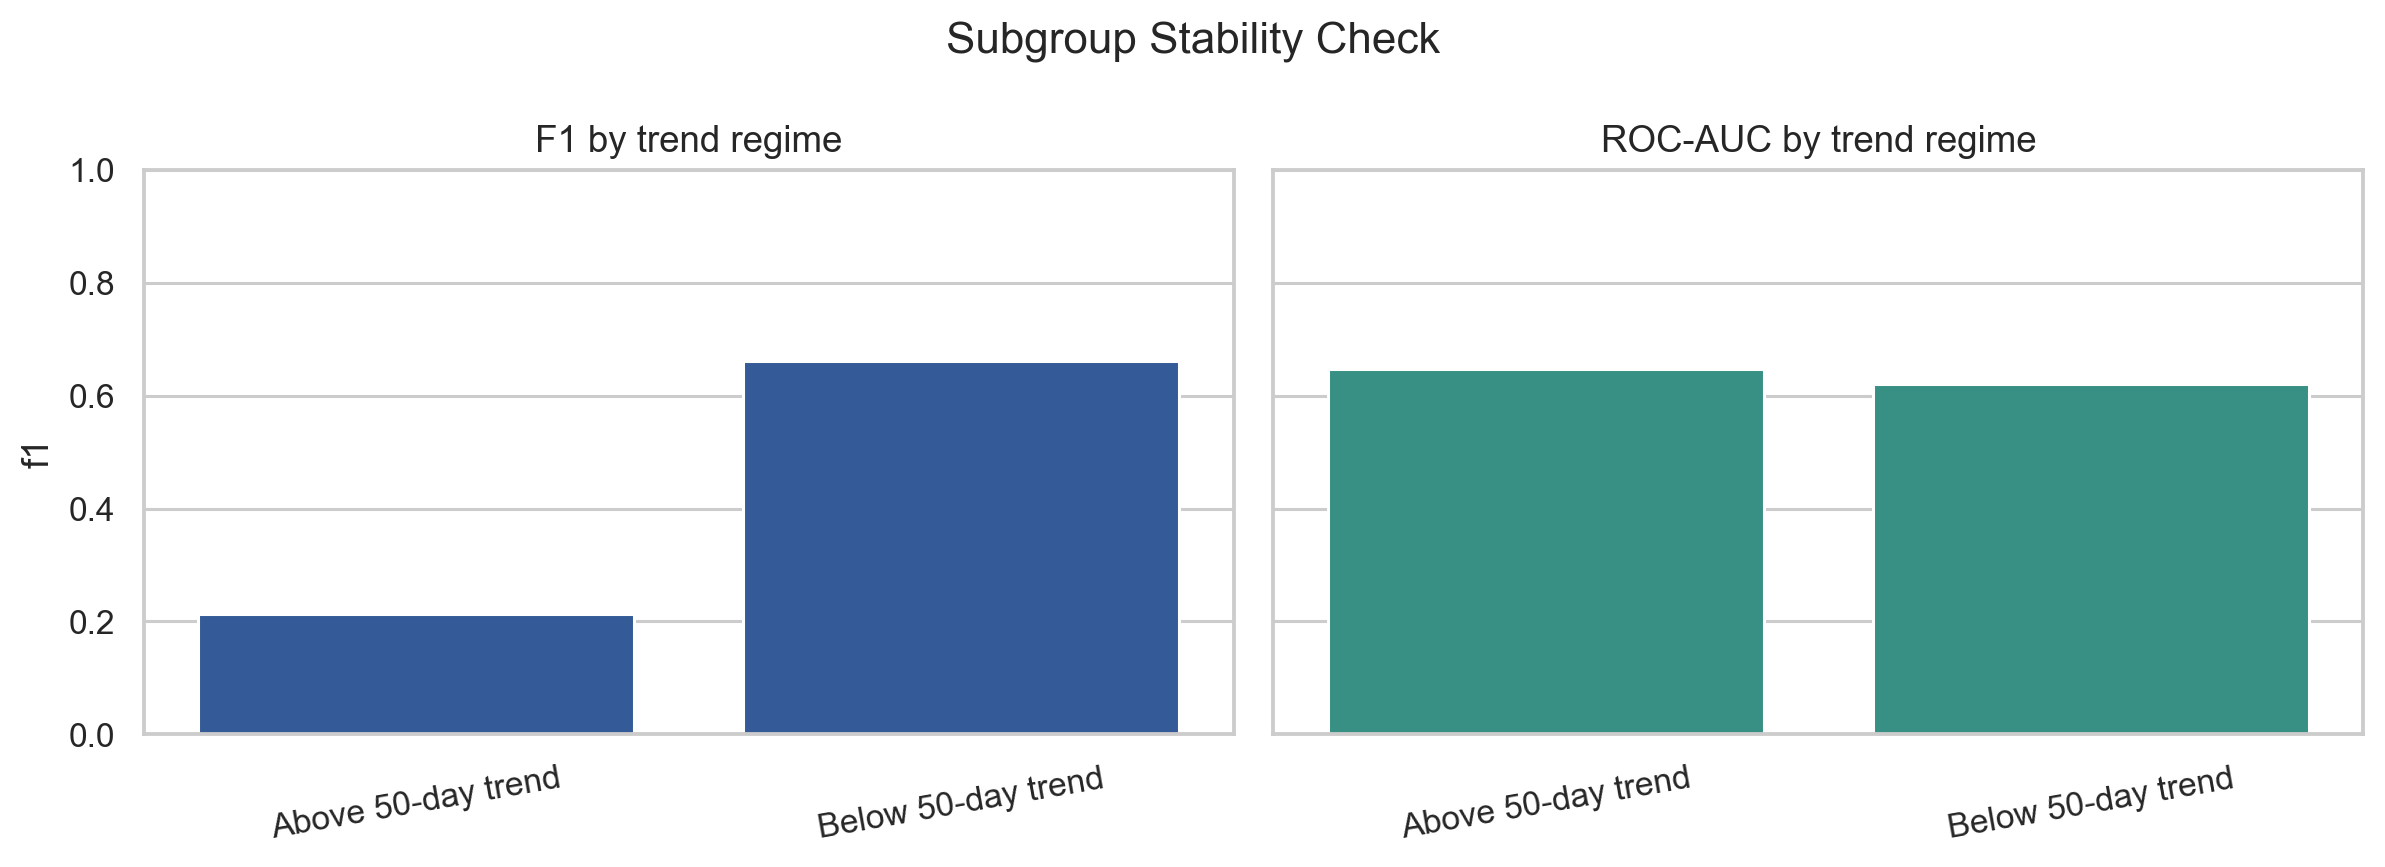

In [3]:
paths = [Path('reports/images/price_and_volatility.png'), Path('reports/images/feature_coefficients.png'), Path('reports/images/scenario_sensitivity.png'), Path('reports/images/subgroup_performance.png')]
for path in paths:
    print(path.name)
    display(Image(filename=str(path)))


## Interpretation
Volatility clusters over time, so random train/test shuffling would leak regime information. The project therefore uses a chronological split. Outliers are flagged with a robust MAD rule but retained because extreme returns are central to the stakeholder's risk question. Correlations are used only to describe relationships and screen redundant inputs; they are not treated as causal evidence.